In [1]:
from sklearn import linear_model
reg = linear_model.LinearRegression()
reg.fit([[0,0], [1, 1], [2, 2]], [0, 1, 2])  # (x1,x2)->(y)
print(reg.coef_) # 线性系数
print(reg.intercept_) # 偏置

[0.5 0.5]
1.1102230246251565e-16


## OLS and Ridge Regression

In [8]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split # 划分数据集
X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False) # 默认随机打乱再分割,此处设置为False,直接取前train_size个样本作为训练集,剩下的test_size作为测试集,train_size和test_size可以写0到1的小数(比例)或者整数(样本数量)
print(y_test)
boo = (y[-20:] == y_test).all() # 验证划分是否正确 .all()方法用于判断数组中所有元素是否满足条件,如果满足返回True,否则返回False.
print(boo)

[233.  91. 111. 152. 120.  67. 310.  94. 183.  66. 173.  72.  49.  64.
  48. 178. 104. 132. 220.  57.]
True


In [9]:
from sklearn.linear_model import LinearRegression, Ridge
regressor = LinearRegression().fit(X_train, y_train)

In [11]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = regressor.predict(X_test)
print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 2548.07
Coefficient of determination: 0.47


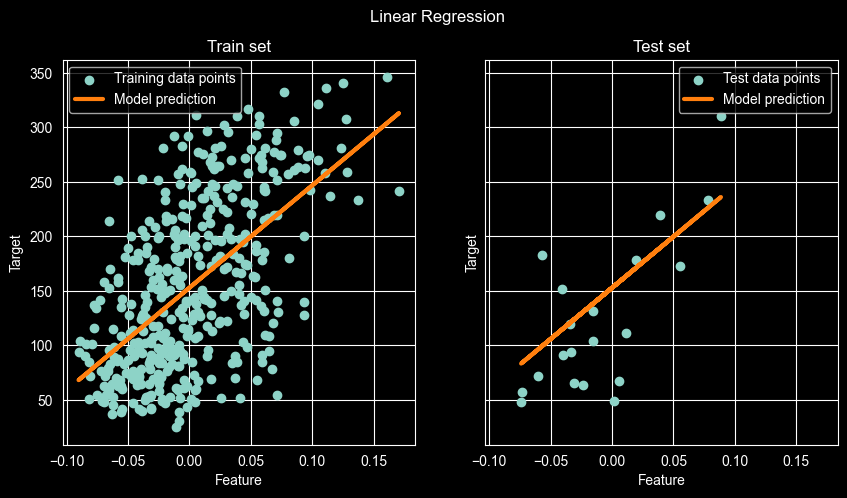

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label="Training data points")
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color="tab:orange",  # 标准Tableau橙色
    label="Model prediction"
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test, y_test, label="Test data points")
ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Model prediction")
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")
plt.show()

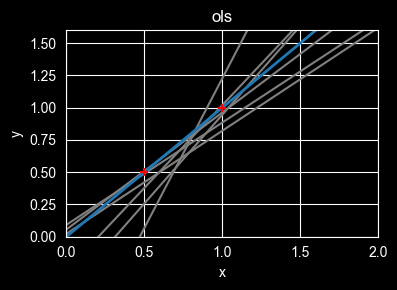

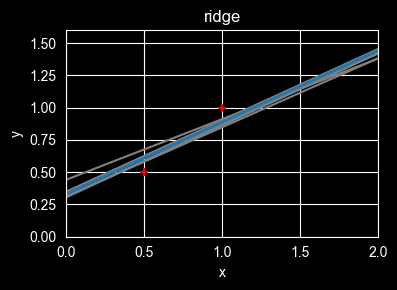

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model

X_train = np.c_[0.5,1].T
y_train = [0.5, 1]
X_test = np.c_[0, 2].T

np.random.seed(0)

classifiers = dict(
    ols=linear_model.LinearRegression(), ridge=linear_model.Ridge(alpha=0.1)
)

for name, clf in classifiers.items():
    fig, ax = plt.subplots(figsize=(4,3))

    for _ in range(6):
        this_X = 0.1 * np.random.normal(size=(2, 1)) + X_train
        clf.fit(this_X, y_train)

        ax.plot(X_test, clf.predict(X_test), color="gray")
        ax.scatter(X_train, y_train, s=3, c="red", marker="+", zorder=10)

    clf.fit(X_train, y_train)
    ax.plot(X_test, clf.predict(X_test), linewidth=2, color="tab:blue")
    ax.scatter(X_train, y_train, s=30, c="red", marker="+", zorder=10) # s 点的大小 zorder 图层顺序,数值越大越靠前
    ax.set_title(name)
    ax.set_xlim(0,2)
    ax.set_ylim(0,1.6)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    fig.tight_layout()

plt.show()

## Ridge更稳